# Gradient Descent, Loss Functions, and Backpropagation

This notebook develops the optimization mechanics that underlie neural-network training.
A tabular grade dataset is used to move from explicit NumPy gradients to PyTorch automatic
differentiation and then to logistic classification with alternative loss functions.

## Topics

- Multivariable linear models
- Mean-squared-error loss
- Explicit gradient calculations
- Weight and bias updates
- PyTorch autograd
- Sigmoid activation
- Binary classification
- Binary cross-entropy
- Backpropagation through the chain rule

Two binary target definitions are explored because they represent different modeling choices:

1. **Final grade ≥ 70** vs. below 70
2. **Letter grade F** vs. all non-F grades

## 1. Environment and Data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from google.colab import files

# Upload the dataset from your computer
uploaded = files.upload()

# Get the uploaded file name
data_path = Path(next(iter(uploaded)))

# Load the Excel file
df = pd.read_excel(data_path)

df.head()

Saving grades.xlsx to grades.xlsx


,Exam 1,Quiz 1,Lab 1,Final Grade,Letter
0,81.882163,69.717432,70.105509,74.682705,C
1,45.477935,82.650857,69.276236,60.253443,D
2,92.290039,55.665642,97.743709,74.759426,C
3,62.506001,101.596774,48.535491,85.601871,B
4,87.178208,91.897542,47.053463,92.676490,A


## 2. Continuous Grade Prediction with NumPy

The linear model is

$$
\hat{y} = XW + b
$$

where:

- $X$ is the input feature matrix,
- $W$ is the weight vector,
- $b$ is the bias term, and
- $\hat{y}$ is the predicted final grade.

The model is trained using the half mean-squared error loss:

$$
L = \frac{1}{2n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2
$$

where $n$ is the number of observations and $y_i$ is the actual final grade.

The gradients of the loss with respect to the weights and bias are calculated explicitly and used to iteratively update the model parameters through gradient descent.

In [2]:
X = df[['Exam 1', 'Quiz 1', 'Lab 1']].to_numpy()
y = df['Final Grade'].to_numpy()

W = np.ones(3)/3
b = 0

learning_rate = 1e-5
num_iterations = 5000
display_step = num_iterations//10
loss_list = []
# Gradient Descent
for i in range(num_iterations):
    y_pred = np.matmul(X, W) + b  # Model prediction
    loss = np.mean((y_pred - y)**2)/2 # Mean Squared Error loss
    loss_list.append(loss)
    # Calculate gradients
    gradients_w = np.matmul(X.T, (y_pred - y))/len(y)
    gradient_b = np.mean(y_pred - y)
    # Update weights
    W -= learning_rate * gradients_w
    b -= learning_rate * gradient_b
    if i % display_step == 0:
      print(f"Iteration {i}, Loss: {loss:.4f} Weights: {W} Bias:{b}")
      print(f"Iteration {i}, Gradients: {gradients_w} {gradient_b }")

print(f"\nFinal Weights: {W} Bias:{b}")
print(f"Final loss: Loss: {loss:.4f}")

Iteration 0, Loss: 54.7435 Weights: [0.33543457 0.33567896 0.3330455 ] Bias:1.70261611649438e-05
Iteration 0, Gradients: [-210.12365297 -234.56270783   28.78288934] -1.7026161164943798
Iteration 500, Loss: 4.0746 Weights: [ 0.51885531  0.50206294 -0.02217175] Bias:-8.595848060695861e-05
Iteration 500, Gradients: [-16.11995106  -6.33793083  24.04928841] -0.04934597924036677
Iteration 1000, Loss: 2.8229 Weights: [ 0.56396701  0.50845903 -0.07685823] Bias:0.00028150239766170607
Iteration 1000, Gradients: [-4.52551889  0.78790556  3.89608121] -0.08640980155648537
Iteration 1500, Loss: 2.7588 Weights: [ 0.5771795   0.50435065 -0.08622403] Bias:0.0007318853028042969
Iteration 1500, Gradients: [-1.39444867  0.65216237  0.7459016 ] -0.09210359068192804
Iteration 2000, Loss: 2.7531 Weights: [ 0.58133754  0.50214254 -0.08815772] Bias:0.0011955541251264348
Iteration 2000, Gradients: [-0.44928034  0.26988092  0.17472506] -0.09309966487022273
Iteration 2500, Loss: 2.7524 Weights: [ 0.58268941  0.50

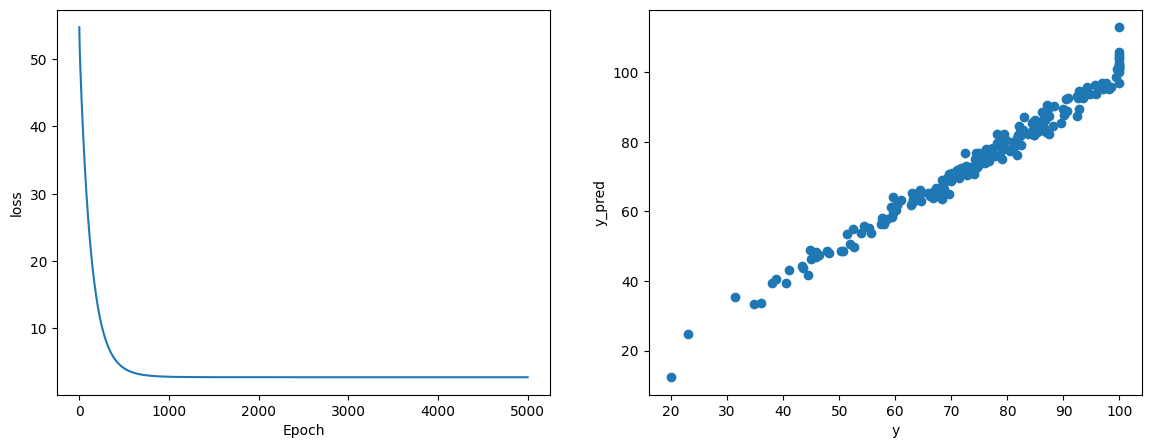

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(loss_list)
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('loss')
ax[1].scatter(y,y_pred)
ax[1].set_xlabel('y')
ax[1].set_ylabel('y_pred')
plt.show()

## 3. The Same Optimization with PyTorch Autograd

The forward model and loss remain the same. PyTorch constructs the computational graph and
obtains parameter gradients with `loss.backward()`.

In [4]:
import torch

In [5]:
X = df[['Exam 1', 'Quiz 1', 'Lab 1']].to_numpy()
y = df['Final Grade'].to_numpy()

W = torch.tensor(np.ones(3)/3, requires_grad=True)
b = torch.tensor(0., requires_grad=True)
X = torch.tensor(X)
y = torch.tensor(y)

learning_rate = 1e-5
num_iterations = 5000
display_step = num_iterations//10
loss_list = []
# Gradient Descent
for i in range(num_iterations):
    y_pred = torch.matmul(X, W) + b  # Model prediction
    loss = torch.mean((y_pred - y)**2)/2 # Mean Squared Error loss
    loss_list.append(loss.item())
    loss.backward()
    # Update weights
    W.data = W.data - learning_rate * W.grad.data
    b.data = b.data - learning_rate * b.grad.data
    # Zeroing gradients after each iteration
    if i % display_step == 0:
      print(f"Iteration {i}, Loss: {loss.item():.4f} Weights: {W.data} Bias:{b.data}")
      print(f"Iteration {i}, Gradients: {W.grad.data} {b.grad.data}")

    W.grad.data.zero_()
    b.grad.data.zero_()

print(f"\nFinal Weights: {W} Bias:{b}")
print(f"Final loss: Loss: {loss.item():.4f}")

Iteration 0, Loss: 54.7435 Weights: tensor([0.3354, 0.3357, 0.3330], dtype=torch.float64) Bias:1.7026161003741436e-05
Iteration 0, Gradients: tensor([-210.1237, -234.5627,   28.7829], dtype=torch.float64) -1.7026160955429077
Iteration 500, Loss: 4.0746 Weights: tensor([ 0.5189,  0.5021, -0.0222], dtype=torch.float64) Bias:-8.595849067205563e-05
Iteration 500, Gradients: tensor([-16.1200,  -6.3379,  24.0493], dtype=torch.float64) -0.04934597760438919
Iteration 1000, Loss: 2.8229 Weights: tensor([ 0.5640,  0.5085, -0.0769], dtype=torch.float64) Bias:0.00028150243451818824
Iteration 1000, Gradients: tensor([-4.5255,  0.7879,  3.8961], dtype=torch.float64) -0.0864097997546196
Iteration 1500, Loss: 2.7588 Weights: tensor([ 0.5772,  0.5044, -0.0862], dtype=torch.float64) Bias:0.0007318852585740387
Iteration 1500, Gradients: tensor([-1.3944,  0.6522,  0.7459], dtype=torch.float64) -0.09210359305143356
Iteration 2000, Loss: 2.7531 Weights: tensor([ 0.5813,  0.5021, -0.0882], dtype=torch.float6

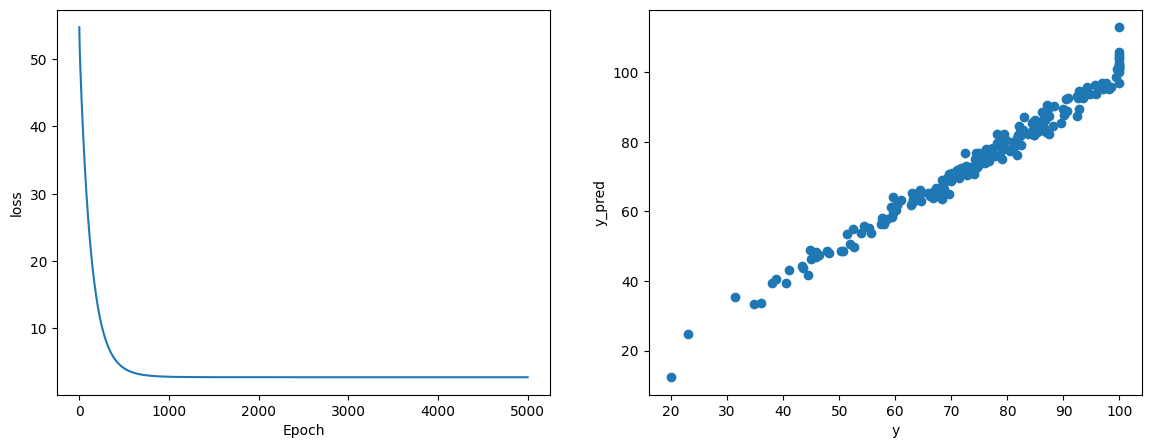

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(loss_list)
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('loss')
ax[1].scatter(y.detach().numpy(),y_pred.detach().numpy())
ax[1].set_xlabel('y')
ax[1].set_ylabel('y_pred')
plt.show()

## 4. Logistic Classification: Final Grade Threshold

The continuous target is converted to a binary outcome using a threshold of 70. A sigmoid
activation maps the linear output to the interval `(0, 1)`.

Iteration 0, Loss: 0.1250 Weights: [0.00368098 0.00387565 0.00197426] Bias:3e-05
Iteration 0, Gradients: [-3.68097782 -3.87564925 -1.9742623 ] -0.03
Iteration 200, Loss: 0.0736 Weights: [ 0.03704126  0.02396133 -0.05266792] Bias:-0.001982185828167456
Iteration 200, Gradients: [-0.06868136 -0.01906645  0.08248128] 0.009192025946041476
Iteration 400, Loss: 0.0726 Weights: [ 0.04557866  0.02613475 -0.06268144] Bias:-0.0037699716994724053
Iteration 400, Gradients: [-0.02598279 -0.00639798  0.03011989] 0.008766278213893539
Iteration 600, Loss: 0.0724 Weights: [ 0.04915833  0.02703701 -0.06683958] Bias:-0.0055045149677198195
Iteration 600, Gradients: [-0.01202512 -0.00313641  0.0140196 ] 0.008601628625744285
Iteration 800, Loss: 0.0724 Weights: [ 0.0508888   0.02749973 -0.06886109] Bias:-0.007216042035381107
Iteration 800, Gradients: [-0.0060674  -0.00166665  0.00709561] 0.00852293788654752
Iteration 1000, Loss: 0.0724 Weights: [ 0.05178078  0.02774873 -0.06990226] Bias:-0.008916103339181542

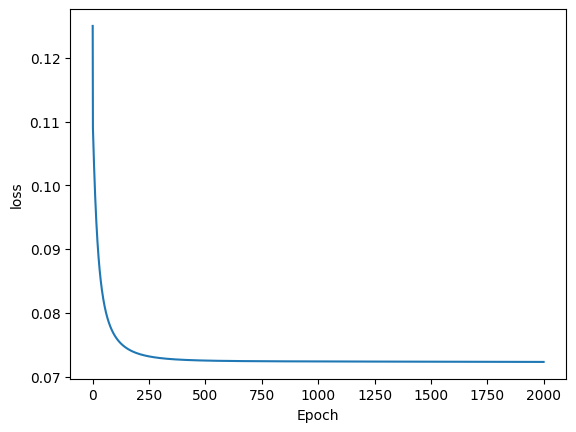

In [7]:
X = df[['Exam 1', 'Quiz 1', 'Lab 1']].to_numpy()
y = df['Final Grade'].to_numpy()
y = np.int16(y>=70)

W = np.zeros(3)
b = 0

learning_rate = 1e-3
num_iterations = 2000
display_step = num_iterations//10
loss_list = []
# Gradient Descent
for i in range(num_iterations):
    z = np.matmul(X, W) + b
    y_pred = 1/(1+np.exp(-z))
    loss = np.mean((y_pred - y)**2)/2 # Mean Squared Error loss
    loss_list.append(loss)
    # Calculate gradients
    gradients_w = np.matmul(X.T, (y_pred - y)*(y_pred)*(1-y_pred))/len(y)
    gradient_b = np.mean((y_pred - y)*(y_pred)*(1-y_pred))
    # Update weights
    W -= learning_rate * gradients_w
    b -= learning_rate * gradient_b
    if i % display_step == 0:
      print(f"Iteration {i}, Loss: {loss:.4f} Weights: {W} Bias:{b}")
      print(f"Iteration {i}, Gradients: {gradients_w} {gradient_b }")

print(f"\nFinal Weights: {W} Bias:{b}")
print(f"Final loss: Loss: {loss:.4f}")

fig, ax = plt.subplots(1)
ax.plot(loss_list)
ax.set_xlabel('Epoch')
ax.set_ylabel('loss')

plt.show()

In [8]:
y_pred_class = np.int16(y_pred>0.5)
print('Accuracy =',np.mean(y_pred_class==y))

Accuracy = 0.765


### 4.1 PyTorch implementation with mean-squared error

In [9]:
X = df[['Exam 1', 'Quiz 1', 'Lab 1']].to_numpy()
y = df['Final Grade'].to_numpy()
y = np.int16(y>=70)

W = torch.tensor(np.zeros(3), requires_grad=True)
b = torch.tensor(0., requires_grad=True)
X = torch.tensor(X)
y = torch.tensor(y)

learning_rate = 1e-3
num_iterations = 2000
display_step = num_iterations//10
loss_list = []
# Gradient Descent
for i in range(num_iterations):
    z = torch.matmul(X, W) + b
    y_pred = 1/(1+torch.exp(-z))
    loss = torch.mean((y_pred - y)**2)/2 # Mean Squared Error loss
    loss_list.append(loss.item())
    loss.backward()
    # Update weights
    W.data = W.data - learning_rate * W.grad.data
    b.data = b.data - learning_rate * b.grad.data
    # Zeroing gradients after each iteration
    if i % display_step == 0:
      print(f"Iteration {i}, Loss: {loss.item():.4f} Weights: {W.data} Bias:{b.data}")
      print(f"Iteration {i}, Gradients: {W.grad.data} {b.grad.data}")

    W.grad.data.zero_()
    b.grad.data.zero_()

print(f"\nFinal Weights: {W} Bias:{b}")
print(f"Final loss: Loss: {loss.item():.4f}")

y_pred_class = np.int16(y_pred>0.5)
print('Accuracy = ',np.mean(y_pred_class==y.detach().numpy()))

Iteration 0, Loss: 0.1250 Weights: tensor([0.0037, 0.0039, 0.0020], dtype=torch.float64) Bias:3.000000106112566e-05
Iteration 0, Gradients: tensor([-3.6810, -3.8756, -1.9743], dtype=torch.float64) -0.029999999329447746
Iteration 200, Loss: 0.0736 Weights: tensor([ 0.0370,  0.0240, -0.0527], dtype=torch.float64) Bias:-0.0019821850582957268
Iteration 200, Gradients: tensor([-0.0687, -0.0191,  0.0825], dtype=torch.float64) 0.00919202622026205
Iteration 400, Loss: 0.0726 Weights: tensor([ 0.0456,  0.0261, -0.0627], dtype=torch.float64) Bias:-0.00376997166313231
Iteration 400, Gradients: tensor([-0.0260, -0.0064,  0.0301], dtype=torch.float64) 0.008766278624534607
Iteration 600, Loss: 0.0724 Weights: tensor([ 0.0492,  0.0270, -0.0668], dtype=torch.float64) Bias:-0.005504513159394264
Iteration 600, Gradients: tensor([-0.0120, -0.0031,  0.0140], dtype=torch.float64) 0.008601628243923187
Iteration 800, Loss: 0.0724 Weights: tensor([ 0.0509,  0.0275, -0.0689], dtype=torch.float64) Bias:-0.00721

### 4.2 PyTorch implementation with binary cross-entropy

Iteration 0, Loss: 0.6931 Weights: tensor([0.0015, 0.0016, 0.0008], dtype=torch.float64) Bias:1.1999999514955562e-05
Iteration 0, Gradients: tensor([-14.7239, -15.5026,  -7.8970], dtype=torch.float64) -0.11999999731779099
Iteration 500, Loss: 0.4430 Weights: tensor([ 0.0433,  0.0271, -0.0610], dtype=torch.float64) Bias:-0.002204187912866473
Iteration 500, Gradients: tensor([-0.3401, -0.0689,  0.3926], dtype=torch.float64) 0.042873140424489975
Iteration 1000, Loss: 0.4378 Weights: tensor([ 0.0534,  0.0286, -0.0721], dtype=torch.float64) Bias:-0.004329509101808071
Iteration 1000, Gradients: tensor([-0.1123, -0.0113,  0.1172], dtype=torch.float64) 0.04228586703538895
Iteration 1500, Loss: 0.4372 Weights: tensor([ 0.0569,  0.0289, -0.0757], dtype=torch.float64) Bias:-0.006439076736569405
Iteration 1500, Gradients: tensor([-0.0413, -0.0037,  0.0422], dtype=torch.float64) 0.0421251505613327
Iteration 2000, Loss: 0.4370 Weights: tensor([ 0.0582,  0.0290, -0.0770], dtype=torch.float64) Bias:-0

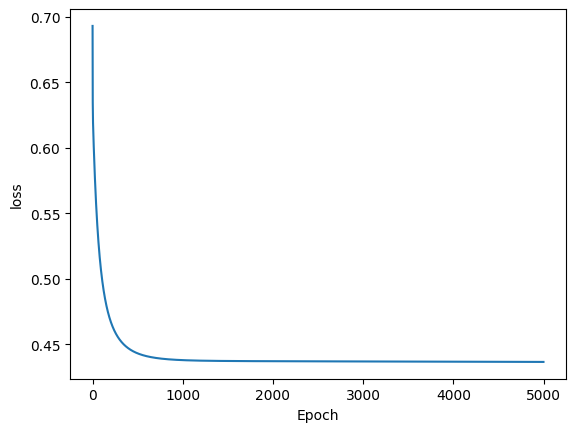

In [10]:
X = df[['Exam 1', 'Quiz 1', 'Lab 1']].to_numpy()
y = df['Final Grade'].to_numpy()
y = np.float64(y>=70)

W = torch.tensor(np.zeros(3), requires_grad=True)
b = torch.tensor(0., requires_grad=True)
X = torch.tensor(X)
y = torch.tensor(y)

learning_rate = 1e-4
num_iterations = 5000
display_step = num_iterations//10
loss_list = []
# Gradient Descent
for i in range(num_iterations):
    z = torch.matmul(X, W) + b
    y_pred = 1/(1+torch.exp(-z))
    loss = -torch.mean((y * torch.log(y_pred) + (1 - y) * torch.log(1 - y_pred)))
    loss_list.append(loss.item())
    loss.backward()
    # Update weights
    W.data = W.data - learning_rate * W.grad.data
    b.data = b.data - learning_rate * b.grad.data
    # Zeroing gradients after each iteration
    if i % display_step == 0:
      print(f"Iteration {i}, Loss: {loss.item():.4f} Weights: {W.data} Bias:{b.data}")
      print(f"Iteration {i}, Gradients: {W.grad.data} {b.grad.data}")

    W.grad.data.zero_()
    b.grad.data.zero_()

print(f"\nFinal Weights: {W} Bias:{b}")
print(f"Final loss: Loss: {loss.item():.4f}")

y_pred_class = np.int16(y_pred>0.5)
print('Accuracy = ',np.mean(y_pred_class==y.detach().numpy()))

fig, ax = plt.subplots(1)
ax.plot(loss_list)
ax.set_xlabel('Epoch')
ax.set_ylabel('loss')

plt.show()



## 5. Logistic Classification: Letter-Grade Definition

A second formulation defines **F = 0** and **A/B/C/D = 1**. This differs from the numeric-threshold target above and therefore represents a separate binary classification problem.

For logistic regression, the linear model output is

$$
z = XW + b
$$

and the sigmoid function converts this value into a probability:

$$
\hat{y} = \sigma(z)
$$

where

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

The NumPy implementation below explicitly applies the chain rule to compute the gradient of the loss with respect to the weights:

$$
\frac{\partial L}{\partial W}
=
X^T
\left[
\frac{\partial L}{\partial \hat{y}}
\frac{\partial \hat{y}}{\partial z}
\right]
$$

The resulting gradients are then used to update the weights and bias during gradient descent.

In [11]:
y = df['Letter'].map(lambda g: 0 if g == 'F' else 1).to_numpy().astype(float)

In [20]:
# Input features
X = df[['Exam 1', 'Quiz 1', 'Lab 1']].to_numpy(dtype=float)

# Binary target:
# F = 0
# A, B, C, D = 1
y = df['Letter'].map(lambda g: 0 if g == 'F' else 1).to_numpy(dtype=float)

# Standardize the input features
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X = (X - X_mean) / X_std


def sigmoid(z):
    out = np.empty_like(z, dtype=float)

    pos = z >= 0
    neg = ~pos

    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))

    ez = np.exp(z[neg])
    out[neg] = ez / (1.0 + ez)

    return out


# Initialize parameters
W = np.zeros(3)
b = 0.0

learning_rate = 0.1
num_iterations = 5000
display_step = max(1, num_iterations // 10)

loss_list = []

N = len(y)


# Gradient Descent
for i in range(num_iterations):

    # Forward pass
    z = np.matmul(X, W) + b
    y_pred = sigmoid(z)

    # Mean Squared Error loss
    loss = np.mean((y_pred - y) ** 2) / 2
    loss_list.append(loss)

    # Backward pass using the chain rule
    dL_dyhat = (y_pred - y) / N

    dyhat_dz = y_pred * (1.0 - y_pred)

    dL_dz = dL_dyhat * dyhat_dz

    # Calculate gradients
    gradients_w = np.matmul(X.T, dL_dz)
    gradient_b = np.sum(dL_dz)

    # Update parameters
    W -= learning_rate * gradients_w
    b -= learning_rate * gradient_b

    if i % display_step == 0:
        print(
            f"Iteration {i}, "
            f"Loss: {loss:.6f}, "
            f"Weights: {W}, "
            f"Bias: {b:.6f}"
        )


# Final probabilities
y_prob = sigmoid(np.matmul(X, W) + b)

# Convert probabilities into classes
y_pred = (y_prob >= 0.5).astype(int)


print("\nFinal Parameters")
print("Weights:", W)
print("Bias:", b)
print("Final loss:", loss)

print("\nAccuracy:", np.mean(y_pred == y))

Iteration 0, Loss: 0.125000, Weights: [ 0.00576359  0.00617043 -0.0005603 ], Bias: 0.007750
Iteration 500, Loss: 0.029933, Weights: [ 0.83773089  0.91042067 -0.15258164], Bias: 1.346365
Iteration 1000, Loss: 0.022630, Weights: [ 1.11974522  1.21770506 -0.21869927], Bias: 1.768234
Iteration 1500, Loss: 0.019403, Weights: [ 1.31060655  1.42862943 -0.25861017], Bias: 2.046541
Iteration 2000, Loss: 0.017469, Weights: [ 1.45916954  1.59404593 -0.28608015], Bias: 2.261228
Iteration 2500, Loss: 0.016139, Weights: [ 1.58303773  1.73214347 -0.30667213], Bias: 2.438637
Iteration 3000, Loss: 0.015149, Weights: [ 1.69053258  1.85172381 -0.32307336], Bias: 2.591194
Iteration 3500, Loss: 0.014373, Weights: [ 1.78625703  1.95779877 -0.33673651], Bias: 2.725860
Iteration 4000, Loss: 0.013743, Weights: [ 1.87303759  2.05352658 -0.34851213], Bias: 2.846964
Iteration 4500, Loss: 0.013216, Weights: [ 1.95274394  2.14103943 -0.35892904], Bias: 2.957392

Final Parameters
Weights: [ 2.02654055  2.22169497 -0

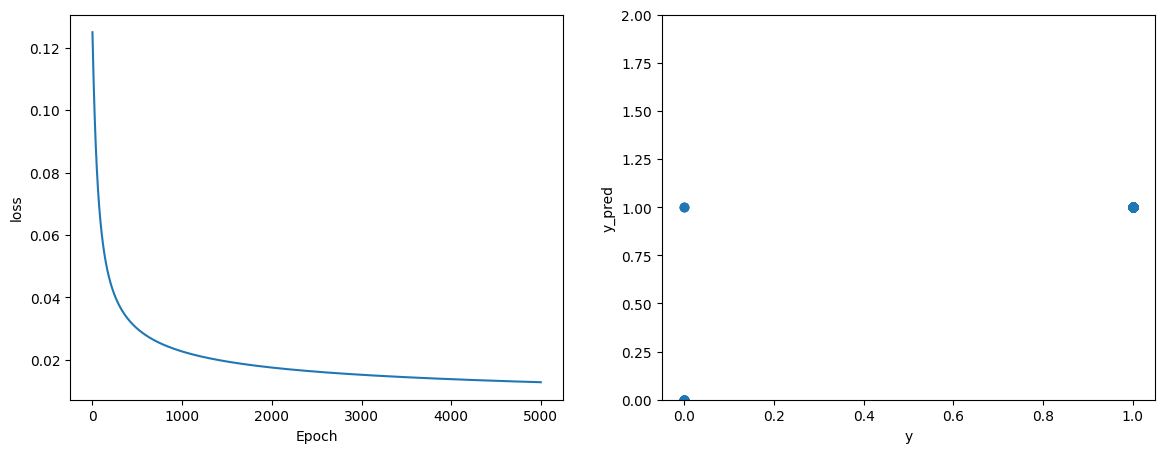

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(loss_list)
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('loss')
ax[1].scatter(y,y_pred)
ax[1].set_xlabel('y')
ax[1].set_ylabel('y_pred')
ax[1].set_ylim(0, 2)
plt.show()

### 5.1 PyTorch autograd with mean-squared error

In [22]:
import torch

In [25]:
# Prepare input features
X_np = df[['Exam 1', 'Quiz 1', 'Lab 1']].to_numpy(dtype=float)

letter_to_label = {
    "A": 1,
    "B": 1,
    "C": 1,
    "D": 1,
    "F": 0
}

y_np = (
    df['Letter']
    .map(letter_to_label)
    .to_numpy(dtype=float)
)

# Standardize the input features
X_mean = X_np.mean(axis=0)
X_std = X_np.std(axis=0)

X_np = (X_np - X_mean) / X_std


# Convert NumPy arrays to PyTorch tensors
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32)


# Initialize parameters
W = torch.zeros(3, dtype=torch.float32, requires_grad=True)
b = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)


learning_rate = 0.1
num_iterations = 5000
display_step = num_iterations // 10

loss_list = []


# Gradient Descent
for i in range(num_iterations):

    # Forward pass
    z = torch.matmul(X, W) + b

    y_prob = torch.sigmoid(z)

    # Mean Squared Error loss
    loss = torch.mean((y_prob - y) ** 2) / 2.0

    loss_list.append(loss.item())


    # Backward pass
    loss.backward()


    # Save gradients before zeroing them
    gradients_w = W.grad.detach().clone()
    gradient_b = b.grad.detach().clone()


    # Update parameters
    with torch.no_grad():

        W -= learning_rate * W.grad
        b -= learning_rate * b.grad


    # Zero gradients for the next iteration
    W.grad.zero_()
    b.grad.zero_()


    if i % display_step == 0:

        print(
            f"Iteration {i}, "
            f"Loss: {loss.item():.6f}, "
            f"Weights: {W.detach().numpy()}, "
            f"Bias: {b.item():.6f}"
        )

        print(
            f"Gradients: {gradients_w.numpy()}, "
            f"{gradient_b.item():.6f}"
        )


# Final probabilities
with torch.no_grad():

    y_prob = torch.sigmoid(torch.matmul(X, W) + b)

    # Convert probabilities to binary classes
    y_pred = (y_prob >= 0.5).int()


# Calculate accuracy
accuracy = (y_pred == y.int()).float().mean()


print("\nFinal Parameters")
print("Weights:", W.detach().numpy())
print("Bias:", b.item())
print("Final loss:", loss.item())
print("Accuracy:", accuracy.item())

Iteration 0, Loss: 0.125000, Weights: [ 0.00576359  0.00617043 -0.0005603 ], Bias: 0.007750
Gradients: [-0.05763588 -0.06170433  0.00560295], -0.077500
Iteration 500, Loss: 0.029933, Weights: [ 0.8377309   0.9104208  -0.15258162], Bias: 1.346365
Gradients: [-0.00736635 -0.00798318  0.00178322], -0.011389
Iteration 1000, Loss: 0.022630, Weights: [ 1.1197451   1.2177051  -0.21869932], Bias: 1.768234
Gradients: [-0.00446363 -0.00490328  0.00098994], -0.006545
Iteration 1500, Loss: 0.019403, Weights: [ 1.310606    1.4286294  -0.25861007], Bias: 2.046541
Gradients: [-0.00330999 -0.00367688  0.00064769], -0.004803
Iteration 2000, Loss: 0.017469, Weights: [ 1.4591705   1.5940453  -0.28607997], Bias: 2.261227
Gradients: [-0.00268742 -0.00299663  0.00046867], -0.003866
Iteration 2500, Loss: 0.016139, Weights: [ 1.5830381  1.7321429 -0.3066722], Bias: 2.438637
Gradients: [-0.00229432 -0.00255603  0.00036372], -0.003271
Iteration 3000, Loss: 0.015149, Weights: [ 1.6905326  1.8517237 -0.3230734], 

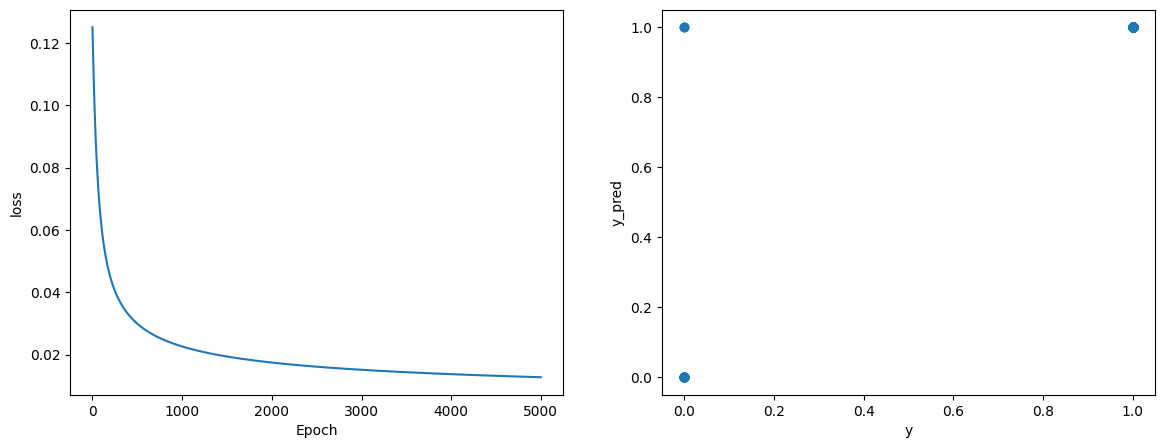

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(loss_list)
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('loss')
ax[1].scatter(y.detach().numpy(),y_pred.detach().numpy())
ax[1].set_xlabel('y')
ax[1].set_ylabel('y_pred')
plt.show()

### 5.2 Binary cross-entropy with PyTorch

In [29]:
import torch
import torch.nn.functional as F
import numpy as np

# Prepare input features
X_np = df[['Exam 1', 'Quiz 1', 'Lab 1']].to_numpy(dtype=float)

# Binary target:
# F = 0
# A, B, C, D = 1
letter_to_label = {
    "A": 1,
    "B": 1,
    "C": 1,
    "D": 1,
    "F": 0
}

y_np = (
    df['Letter']
    .map(letter_to_label)
    .to_numpy(dtype=float)
)

# Standardize input features
X_mean = X_np.mean(axis=0)
X_std = X_np.std(axis=0)

X_np = (X_np - X_mean) / X_std

# Convert to PyTorch tensors
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32)

# Initialize model parameters
W = torch.zeros(3, dtype=torch.float32, requires_grad=True)
b = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)

learning_rate = 0.1
num_iterations = 5000
display_step = num_iterations // 10

loss_list = []

# Gradient Descent
for i in range(num_iterations):

    # Linear output
    z = torch.matmul(X, W) + b

    # Binary Cross-Entropy with logits
    # Sigmoid is handled internally
    loss = F.binary_cross_entropy_with_logits(z, y)

    loss_list.append(loss.item())

    # Backpropagation
    loss.backward()

    # Save gradients before clearing them
    gradients_w = W.grad.detach().clone()
    gradient_b = b.grad.detach().clone()

    # Update parameters
    with torch.no_grad():
        W -= learning_rate * W.grad
        b -= learning_rate * b.grad

    # Clear gradients
    W.grad.zero_()
    b.grad.zero_()

    if i % display_step == 0:
        print(
            f"Iteration {i}, "
            f"Loss: {loss.item():.6f}, "
            f"Weights: {W.detach().numpy()}, "
            f"Bias: {b.item():.6f}"
        )

        print(
            f"Gradients: {gradients_w.numpy()}, "
            f"{gradient_b.item():.6f}"
        )


# Final prediction
with torch.no_grad():

    z = torch.matmul(X, W) + b

    # Convert logits to probabilities
    y_prob = torch.sigmoid(z)

    # Convert probabilities to classes
    y_pred = (y_prob >= 0.5).int()


# Accuracy
accuracy = (y_pred == y.int()).float().mean()

print("\nFinal Parameters")
print("Weights:", W.detach().numpy())
print("Bias:", b.item())
print("Final BCE Loss:", loss.item())
print("Accuracy:", accuracy.item())

Iteration 0, Loss: 0.693147, Weights: [ 0.02305435  0.02468173 -0.00224118], Bias: 0.031000
Gradients: [-0.23054351 -0.2468173   0.02241181], -0.310000
Iteration 500, Loss: 0.119904, Weights: [ 1.835689    1.9914029  -0.33336726], Bias: 2.829554
Gradients: [-0.01452385 -0.01579826  0.00241192], -0.020585
Iteration 1000, Loss: 0.093653, Weights: [ 2.3907628   2.5968497  -0.41167632], Bias: 3.605064
Gradients: [-0.00882705 -0.00963227  0.00105096], -0.012164
Iteration 1500, Loss: 0.081829, Weights: [ 2.7707186   3.0104816  -0.45277095], Bias: 4.123905
Gradients: [-0.00663237 -0.00719687  0.00065655], -0.008975
Iteration 2000, Loss: 0.074678, Weights: [ 3.0695963   3.3336904  -0.48081648], Bias: 4.525691
Gradients: [-0.00542433 -0.00584455  0.00048523], -0.007245
Iteration 2500, Loss: 0.069741, Weights: [ 3.3199937  3.6026053 -0.5025334], Bias: 4.858444
Gradients: [-0.00464239 -0.00496931  0.00039166], -0.006139
Iteration 3000, Loss: 0.066062, Weights: [ 3.5374882  3.8347497 -0.5205352], 

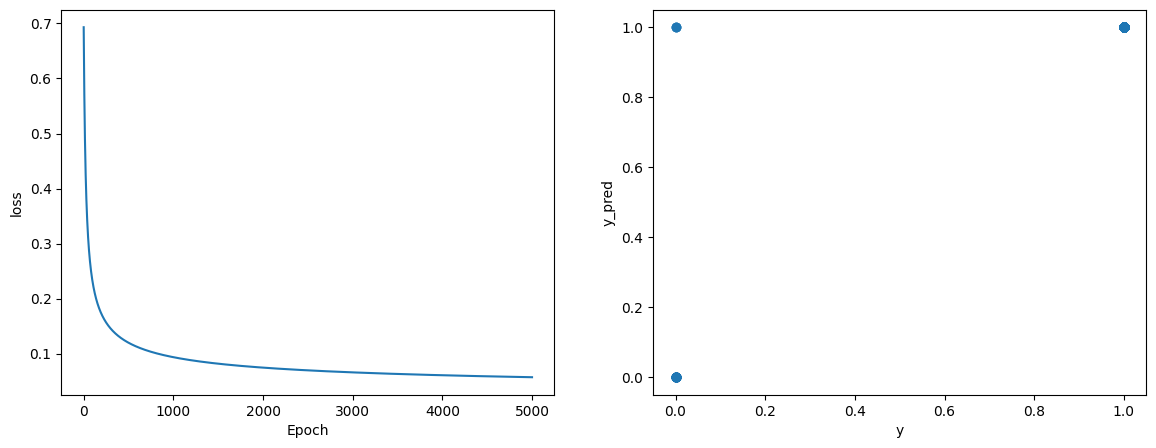

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(loss_list)
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('loss')
ax[1].scatter(y.detach().numpy(),y_pred.detach().numpy())
ax[1].set_xlabel('y')
ax[1].set_ylabel('y_pred')
plt.show()

## 6. Backpropagation and Optimizer Connection

These experiments show the same training mechanism at different levels of abstraction.

- **Loss functions** quantify prediction error.
- **Gradients** measure how model parameters affect the loss.
- **Backpropagation** applies the chain rule through the computational graph.
- **Gradient descent** uses those gradients to update the parameters.
- **Automatic differentiation** performs the derivative bookkeeping while preserving the same mathematics.

The next notebook extends this foundation to TensorFlow/Keras and compares SGD, momentum,
Adam, alternative activations, and alternative loss functions.